# Notebook to fit mocks:

**Remark:** 
 * I work in my local branch of `desi-clustering`: `edmond-dev`
 * For now it turns with `desilike/dr2-dev`

In [1]:
import logging

import os
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

import lsstypes
from clustering_statistics.tools import get_stats_fn

from tools import run_profiling_one_mock

import os
import re
from pathlib import Path
from collections import defaultdict

from tools import get_getdist_plotter, plot_triangle

In [3]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    """ 
    """
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax} 
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax   }   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']

    return propose_fiducial



def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR', nmocks_mean=None, 
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None, nmocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]
    if nmocks is not None:
        kwargs['nmocks'] = nmocks

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    if nmocks_mean is not None:
        # Keep only mocks that are not used in the mean, to have independent mocks for covariance validation and likelihood profiling.
        mean_mock = lsstypes.mean(mock[:nmocks_mean])
        mock = mock[nmocks_mean:]

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    if nmocks_mean is not None:
        return pk, window, cov, zeff, mock, mean_mock
    else:
        return pk, window, cov, zeff, mock

## Load data: 

In [140]:
# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

tracer_to_load = ['LRG', 'QSO', 'LRGxQSO', 'ELGnotqso', 'LRGxELGnotqso', 'ELGnotqsoxQSO'][:]

regions = ['GCcomb', 'NGC', 'SGC']
kmin = 1e-3

nmean = 50  # number of mocks to use for the mean. 

pk, zeff = {}, {}
window, mocks, mean_mocks = {}, {}, {}

std = {}

for tracer in tracer_to_load:

    tracer_to_read = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    pk[tracer], window[tracer], mocks[tracer], mean_mocks[tracer], zeff[tracer], std[tracer] = {}, {}, {}, {}, {}, {}
    for region in regions:
        fiducial = propose_fiducial(kmin=kmin, region=region)

        window[tracer][region], mocks[tracer][region], mean_mocks[tracer][region] = {}, {}, {}

        pk[tracer][region], window[tracer][region]['RIC+AMR'], _, zeff[tracer][region], mocks[tracer][region]['RIC+AMR'] = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra='RIC+AMR')
        # for plotting purpose:
        std[tracer][region] = np.sqrt(np.diag(lsstypes.cov(mocks[tracer][region]['RIC+AMR']).value()))

        for key in ['', 'RIC', 'DR1-RIC', 'DR1-RIC+AMR']:
            if key == '':
                weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle'
            elif key in ['RIC', 'DR1-RIC']:
                weight_type_mocks = 'default-noimsys-fkp-oqe'
            else:
                weight_type_mocks = 'default-fkp-oqe'

            try:
                _, window[tracer][region][key], _, _, mocks[tracer][region][key] = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra=key,
                                                                weight_type_mocks=weight_type_mocks, nmocks=nmean)
            except FileNotFoundError:
                window[tracer][region][key], mocks[tracer][region][key] = None, None

        for key in ['', 'RIC', 'DR1-RIC', 'RIC+AMR', 'DR1-RIC+AMR']:
            mean_mocks[tracer][region][key] = lsstypes.mean(mocks[tracer][region][key][:nmean]) if mocks[tracer][region][key] is not None else None

        if 'ELG' in tracer:
            weight_type_mocks = {
                'ELGnotqso': 'default-fkp-oqe-wsys-imlin',
                'LRGxELGnotqso': 'default-fkp-oqexdefault-fkp-oqe-wsys-imlin',
                'ELGnotqsoxQSO': 'default-fkp-oqe-wsys-imlinxdefault-fkp-oqe',
            }[tracer_to_read]

            if key in ['RIC+AMR', 'DR1-RIC+AMR']:  # only load mocks for this weight type, to save time and disk space.
                tmp = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra='RIC+AMR', weight_type_mocks=weight_type_mocks, nmocks=nmean)[-1]
                mean_mocks[tracer][region]['RIC+AMR'] = lsstypes.mean(tmp)
            else:
                mean_mocks[tracer][region]['RIC+AMR'] = None

        # Load Glam mocks:
        # try:
        #     fns_mock = [get_stats_fn(kind='mesh2_spectrum_poles', stats_dir=mocks_dir, project='glam-uchuu-v2-altmtl', tracer=tracer, region=region, 
        #                              weight='default-fkp-oqe', imock=imock) for imock in range(150, 250) if imock not in [210,243]] 
        #     glams[tracer][region] = [lsstypes.read(fn).match(pk[tracer][region]) for fn in fns_mock]
        #     mean_glams[tracer][region] = lsstypes.mean(glams[tracer][region][:nmean])
        # except KeyError:
        #     glams[tracer][region], mean_glams[tracer][region] = None, None

zeffs = {}
for reg in regions:
    zeffs[reg] = {}
    for tracer in tracer_to_load:
        # for likelihood building:
        tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')
        zeffs[reg][tracer] = zeff[tracer][reg]

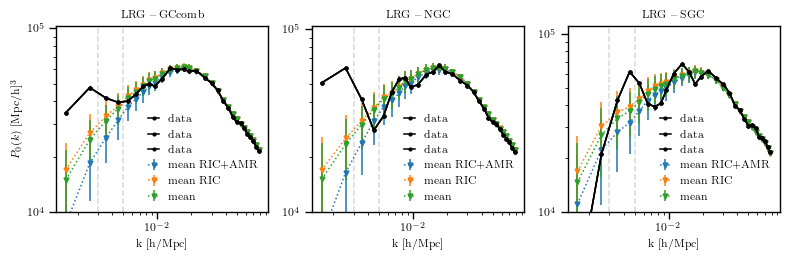

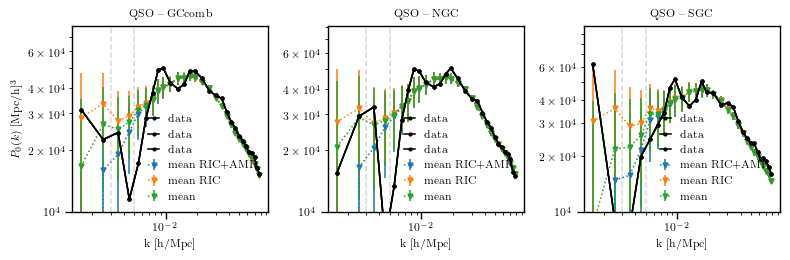

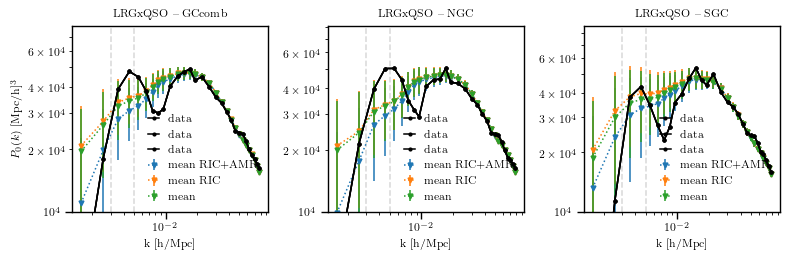

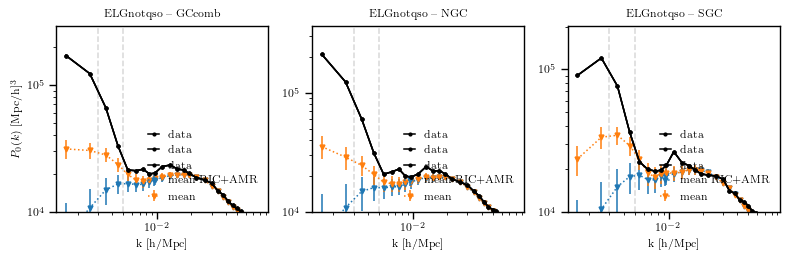

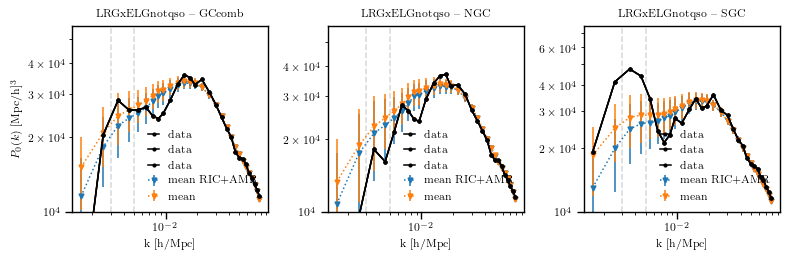

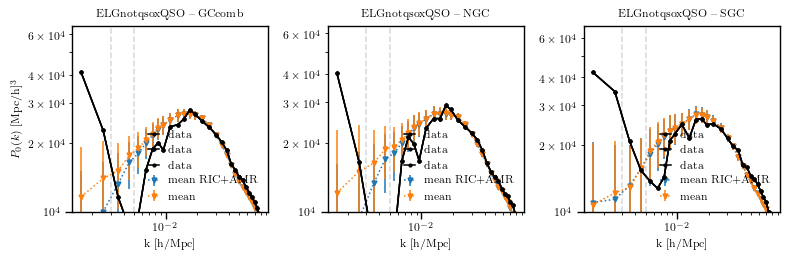

In [141]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    plt.figure(figsize=(8,2.7))

    for i, reg in enumerate(regions):
        plt.subplot(131+i)
        for key in ['RIC+AMR', 'RIC', '']:
            if mean_mocks[tracer][reg][key] is not None:
                size_for_std = mean_mocks[tracer][reg][key].get(0).k.size
                plt.errorbar(mean_mocks[tracer][reg][key].get(0).k, mean_mocks[tracer][reg][key].get(0).value(), yerr=std[tracer][reg][:size_for_std], label=f'mean {key}', marker='v', markersize=3.5, ls=':')

            #if mean_glams[tracer][reg] is not None:
            #    plt.plot(mean_glams[tracer][reg].get(0).k, mean_glams[tracer][reg].get(0).value(), label='mean glams', marker='x', ls='--', zorder=1)

            plt.loglog(pk[tracer][reg].get(0).k, pk[tracer][reg].get(0).value(), label='data', marker='.', c='k', zorder=20)

        plt.axvline(3e-3, ls='--', c='gray', alpha=0.3)
        plt.axvline(5e-3, ls='--', c='gray', alpha=0.3)

        plt.xlabel('k [h/Mpc]')
        if i == 0: plt.ylabel(r'$P_0(k)$ [Mpc/h]$^3$')
        plt.title(f'{tracer_save} -- {reg}')
        plt.ylim(1e4, None)
        plt.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f'fig/mean_mocks_{tracer_save}.png', dpi=400)
    plt.show()

In [9]:
def create_theory(b1=2.0, zeff=0.733, shotnoise=0.0):
    from lsstypes import Mesh2SpectrumPole, Mesh2SpectrumPoles
    from cosmoprimo.fiducial import DESI

    cosmo = DESI(engine='eisenstein_hu')

    f = cosmo.growth_rate(zeff)

    edges = np.linspace(0., 0.3, 1001)
    edges = np.column_stack([edges[:-1], edges[1:]])
    kk = np.mean(edges, axis=-1)

    pk = cosmo.get_fourier().pk_interpolator(of='delta_cb')(kk, z=zeff)
    f = cosmo.growth_rate(zeff)
    shotnoise = np.ones_like(kk) * shotnoise

    ells = (0, 2, 4)
    poles = []
    poles.append((b1**2 + 2. / 3. * f * b1 + 1. / 5. * f**2) * pk + shotnoise)
    poles.append((4. / 3. * f * b1 + 4. / 7. * f**2) * pk)
    poles.append(8. / 35 * f**2 * pk)
    poles = np.array(poles, dtype='f8')

    theo = [Mesh2SpectrumPole(k=kk, k_edges=edges, num_raw=value, num_shotnoise=(ell == 0) * shotnoise, ell=ell) for ell, value in zip(ells, poles)]
    theo = Mesh2SpectrumPoles(theo)

    return theo

def convolve_theory(theo, window, add_shotnoise=False):
    # Rebin the theory to match the input window.
    theo = theo.match(window.theory)

    # value() is read-only; use clone(value=...) to create an updated copy.
    if add_shotnoise:
        values = [theo.get(ell).value().copy() for ell in theo.ells]
        for iell, ell in enumerate(theo.ells):
            if ell == 0:
                values[iell] += theo.get(ell).num_shotnoise / theo.get(ell).norm
                break
        theo = theo.clone(value=np.concatenate(values))

    # Convolve the rebinned theory with the window.
    return window.dot(theo, return_type=None)

In [10]:
if False:
    shotnoise =  (pk.get(0).num_shotnoise / pk.get(0).norm)[0]
    theo = create_theory(b1=2.1, zeff=0.818, shotnoise=shotnoise)
    conv = convolve_theory(theo, window[''])
    conv_w_sn = convolve_theory(theo, window[''], add_shotnoise=True)

    plt.figure(figsize=(6,2.7))
    plt.subplot(131)
    plt.loglog(theo.get(0).k, theo.get(0).value(), label='theory')
    sn = np.ones_like(theo.get(0).k) * theo.get(0).num_shotnoise / theo.get(0).norm
    plt.loglog(theo.get(0).k, sn, c='gray', ls='--', label='shotnoise')
    plt.loglog(theo.get(0).k, theo.get(0).value() + sn, label='theory w. sn')
    sn_data = np.ones_like(pk.get(0).k) * pk.get(0).num_shotnoise / pk.get(0).norm
    plt.loglog(pk.get(0).k, pk.get(0).value() + sn_data, ls='--', c='k', label='data w. sn')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'$P_{0}(k)$ [$(\rm{Mpc}/h)^3$]')
    plt.subplot(132)
    plt.plot(conv_w_sn.get(0).k, (conv.get(0).value() - (conv_w_sn.get(0).value() -  shotnoise)))
    plt.xscale('log')
    plt.axhline(-200, ls='--', c='gray')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'ratio')
    plt.subplot(133)
    plt.plot(conv_w_sn.get(0).k, (conv.get(0).value()), label='conv wo shotnoise')
    plt.loglog(conv_w_sn.get(0).k, (conv_w_sn.get(0).value() -  shotnoise), label='conv with shotnoise')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'P_0(k) [$(\rm{Mpc}/h)^3$]')
    plt.tight_layout()
    plt.show()

/Users/edmond/Developer/Software/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


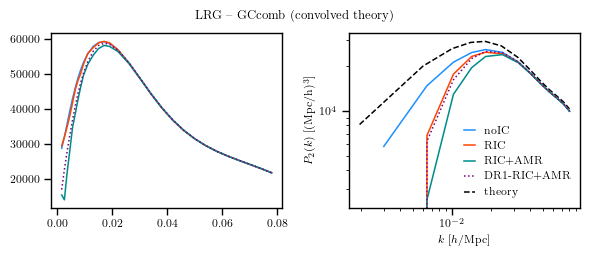

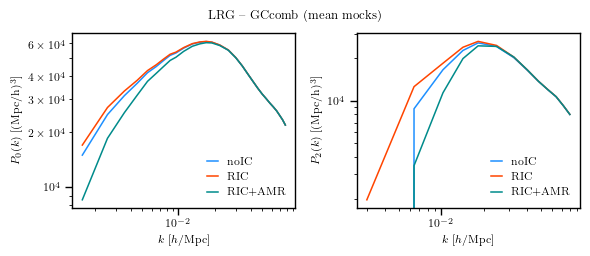

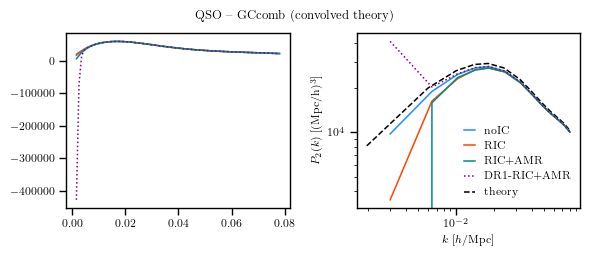

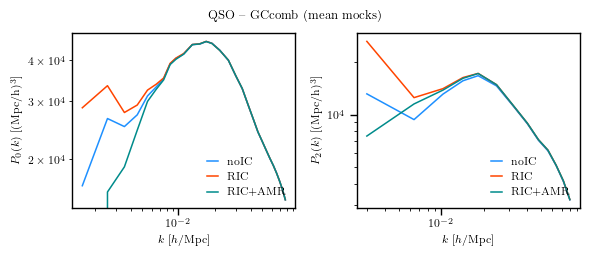

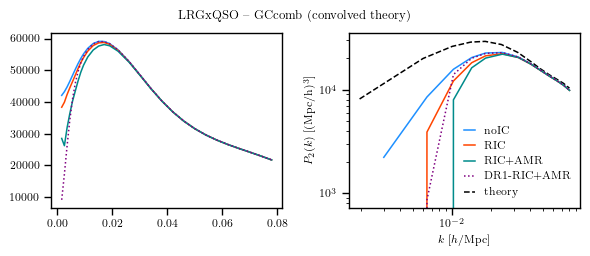

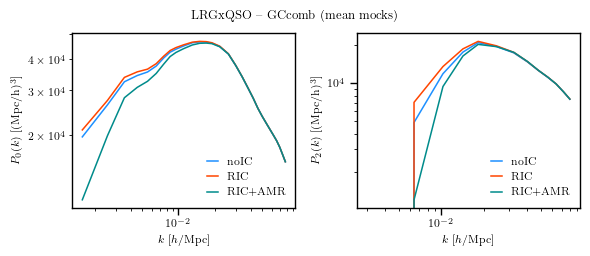

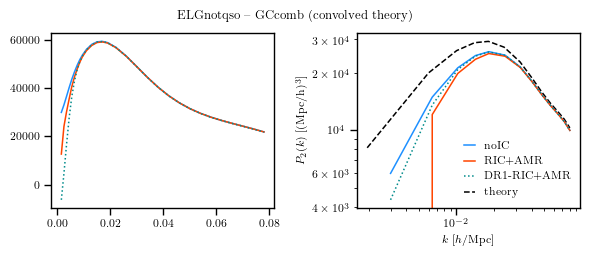

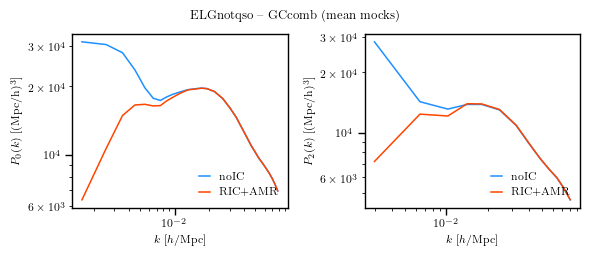

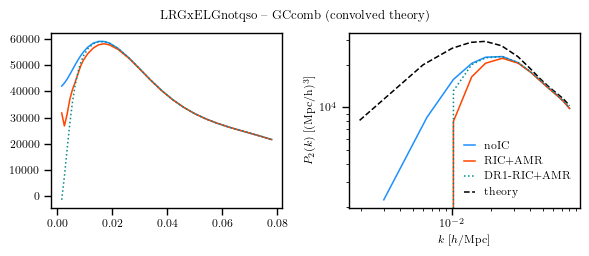

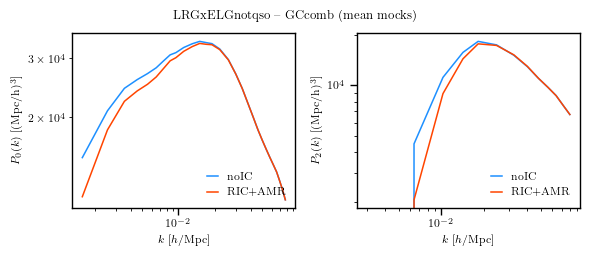

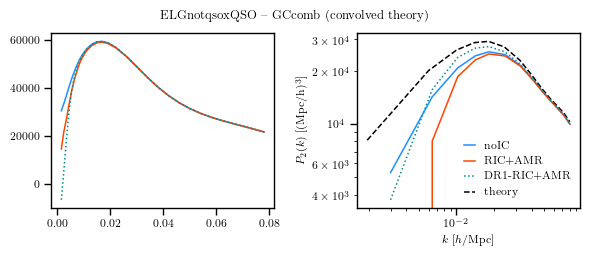

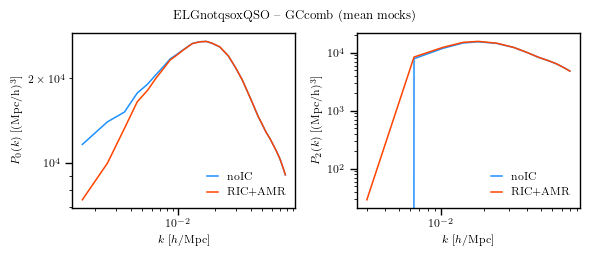

In [11]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    reg = 'GCcomb'

    shotnoise =  (pk[tracer][reg].get(0).num_shotnoise / pk[tracer][reg].get(0).norm)[0]
    theo = create_theory(b1=2.1, zeff=0.818, shotnoise=shotnoise)

    plt.figure(figsize=(6,2.7))

    for i, ell in enumerate([0, 2]):
        plt.subplot(121+i)

        for key in ['', 'RIC', 'RIC+AMR', 'DR1-RIC+AMR']:
            try:
                conv_theo = convolve_theory(theo, window[tracer][reg][key])
                label = 'noIC' if key == '' else key  #it has GIC but not RIC/AMR.
                ls = ':' if 'DR1' in key else '-'
                plt.plot(conv_theo.get(ell).k, conv_theo.get(ell).value(), ls=ls, label=label)
            except AttributeError:
                continue

    tmp = theo.match(conv_theo)
    plt.loglog(tmp.get(ell).k, tmp.get(ell).value(), label='theory', c='k', ls='--', zorder=0)

    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(rf'$P_{ell}(k)$' + r' [$(\rm{Mpc}/h)^3$]')
    plt.legend(loc='lower right')

    plt.suptitle(f'{tracer_save} -- {reg} (convolved theory)', y=0.93, fontsize=9)
    plt.tight_layout()
    plt.show()

        
    plt.figure(figsize=(6,2.7))

    for i, ell in enumerate([0, 2]):
        plt.subplot(121+i)

        for key in ['', 'RIC', 'RIC+AMR']:
            try:
                to_plot = mean_mocks[tracer][reg][key]
                label = 'noIC' if key == '' else key  #it has GIC but not RIC/AMR.
                ls = ':' if 'DR1' in key else '-'
                plt.loglog(to_plot.get(ell).k, to_plot.get(ell).value(), ls='-', label=label)
            except AttributeError:
                continue
        plt.xlabel(r'$k$ [$h/$Mpc]')
        plt.ylabel(rf'$P_{ell}(k)$' + r' [$(\rm{Mpc}/h)^3$]')
        plt.legend(loc='lower right')

    plt.suptitle(f'{tracer_save} -- {reg} (mean mocks)', y=0.93, fontsize=9)
    plt.tight_layout()
    plt.show()


## Let's fit the mean of the mocks...

In [142]:
from tools import get_observable_and_likelihood, run_profiler, run_mcmc, plot_observables

profilers = {}
chains = {}

dir_chains = '/Users/edmond/Work/data/desi-clustering/dr2/chains/local_png/base/holi-v3-altmtl/mean_mocks'
force_mcmc = False  # set to True to re-run MCMC even if chains already exist (use with caution as it can be time-consuming)

burnin, thin = 0.3, 10

for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    if tracer == 'QSOxQSO':
        kmin_prof = [1e-3, 2e-3, 4e-3]
        kmin_chains = [1e-3, 2e-3, 4e-3] 
    elif tracer == 'ELGxELG':
        kmin_prof = [8e-3, 1e-2]
        kmin_chains = [8e-3, 1e-2]
    elif tracer == 'LRGxLRG' or tracer == 'LRGxQSO':
        kmin_prof = [1e-3, 2e-3, 4e-3, 6e-3]
        kmin_chains = [2e-3, 4e-3, 6e-3]
    else:
        kmin_prof = [2e-3, 4e-3, 6e-3]
        kmin_chains = [2e-3, 4e-3, 6e-3]

    for key in tqdm.tqdm(['RIC+AMR']):   #['', 'RIC', 'RIC+AMR'] # 'DR1-RIC', 'DR1-RIC+AMR'
        for region in regions:
            for kmin in kmin_prof:
                try:
                    # Restrict mocks to k>kmin:
                    pp = mean_mocks[tracer][region][key].select(k=(kmin, 1))
                    ww = window[tracer][region][key].at.observable.match(pp)
                    mm = [mock.select(k=(kmin, 1)) for mock in mocks[tracer][region]['RIC+AMR']]   # use 1000 EZmocks

                    from clustering_statistics.tools import bias
                    tt1 = tracer.split('x')[0]
                    kwargs = {f'{tt1}_{tracer}_ell0.b1': bias(zeffs[region][tracer][0], tracer=tt1)}

                    obs, lik = get_observable_and_likelihood(pp, ww, mm, tracer, zeffs[region], engine='camb', fix_fnl=False, nickname=tracer, **kwargs) 
                    profilers[(tracer, region, key, kmin)] = run_profiler(lik)
                    
                    # running chains can be long ... 
                    if key in ['', 'RIC', 'RIC+AMR'] and kmin in kmin_chains:  # only run MCMC for a subset of cases to save time.
                        key_tag = 'noIC' if key == '' else key
                        dir_output = f'{dir_chains}/samples_{tracer_save}_nmean_{nmean}_{region}_{key_tag}_kmin-{kmin:.0e}/'
                        from desilike.samples import MCSamples
                        if not os.path.exists(dir_output) or force_mcmc:  # avoid re-running if chain already exists
                            sampler = run_mcmc(lik, dir_output=dir_output, max_steps=40000, check_every=20000)
                            chains[(tracer, region, key, kmin)] =  MCSamples.concatenate([cc.remove_burnin(burnin)[::thin] for cc in sampler.chains])
                        else:
                            fns = sorted(Path(dir_output).glob('samples_*.h5'))
                            chains[(tracer, region, key, kmin)] = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin)[::thin] for fn in fns])

                    #if kmin == 1e-3:
                    #    print(profilers[(tracer, region, key, kmin)].profiles.to_stats(tablefmt="pretty"))
                    #    plot_observables({tracer: obs}, figsize=(4,3))

                    #plot_observables({tt: obs[tt] for tt in order})

                except AttributeError as e:
                    print(e)
                    continue


    # for region in regions:
    #     print('GLAM ({region}): ')
    #     obs, lik = get_observable_and_likelihood(mean_glams[tracer][region], window[tracer][region]['RIC+AMR'], mocks[tracer][region]['RIC+AMR'], tracer, zeffs[region][tracer], 
    #                                             engine='camb', fix_fnl=False, nickname=tracer)
    #     profiler = run_profiler(lik)
    #     print(profiler.profiles.to_stats(tablefmt="pretty"))
    #     plot_observables({tracer: obs}, figsize=(4,3))

100%|██████████| 1/1 [00:40<00:00, 40.48s/it]


<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

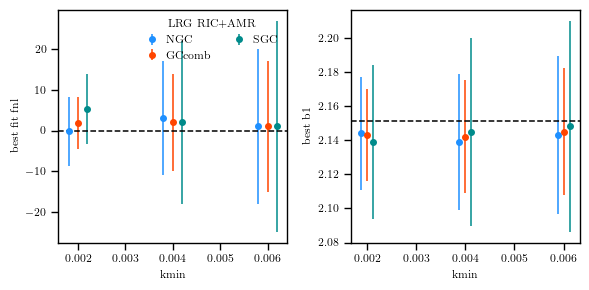

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

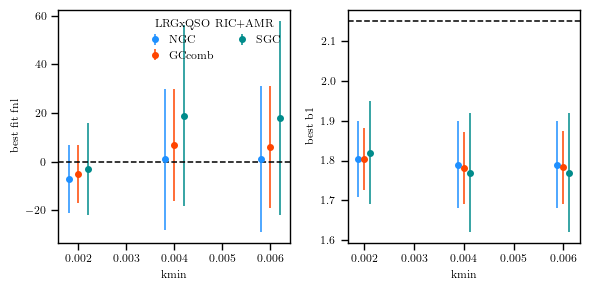

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

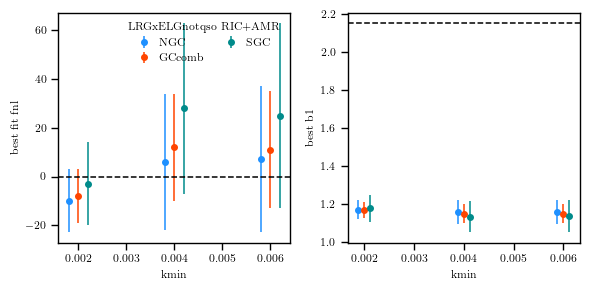

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

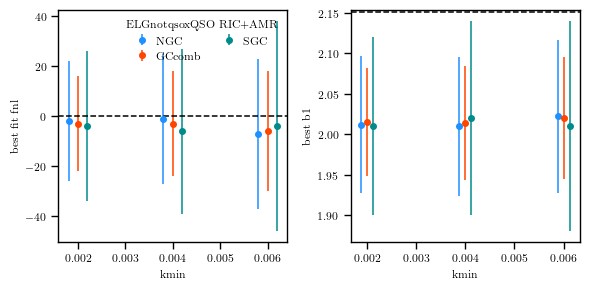

In [112]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for key in ['', 'RIC', 'RIC+AMR']:
        try:
            plt.figure(figsize=(6,3))
            for i, region in enumerate(['NGC', 'GCcomb', 'SGC']):
                fnl, b1 = [], []
                for kmin in kmin_prof:
                    profiler = profilers[(tracer, region, key, kmin)]
 
                    fnl.append([kmin, float(profiler.to_stats(tablefmt="list")[0][3][-2]), float(profiler.to_stats(tablefmt="list")[0][3][-1])])
                    b1.append([kmin, float(profiler.to_stats(tablefmt="list")[0][0][-2]), float(profiler.to_stats(tablefmt="list")[0][0][-1])])
                    
                plt.subplot(121)
                plt.errorbar([t[0] + (i-1)*0.0002 for t in fnl], [t[1] for t in fnl], yerr=[t[2] for t in fnl], marker='o', ls='', label=region)
                plt.subplot(122)
                plt.errorbar([t[0] + (i-1)*0.00012 for t in b1], [t[1] for t in b1], yerr=[t[2] for t in b1], marker='o', ls='')

            plt.subplot(121)
            plt.axhline(0, ls='--', c='k')
            plt.legend(title=tracer_save + ' ' + key, ncol=2)
            plt.xlabel('kmin')
            plt.ylabel('best fit fnl')
            plt.subplot(122)
            plt.axhline(2.151, ls='--', c='k')
            plt.xlabel('kmin')
            plt.ylabel('best b1')
            plt.tight_layout()
            plt.savefig(f'fig/{tracer_save}_{key}_fit_kmin.png', dpi=400)
            plt.show()
        
        except KeyError:
            continue

('LRGxLRG', 'SGC', '', 0.001)
('LRGxLRG', 'SGC', '', 0.003)
('LRGxLRG', 'SGC', '', 0.008)
('LRGxLRG', 'SGC', '', 0.002)
('LRGxLRG', 'SGC', 'RIC', 0.001)
('LRGxLRG', 'SGC', 'RIC', 0.003)
('LRGxLRG', 'SGC', 'RIC', 0.008)
('LRGxLRG', 'SGC', 'RIC', 0.002)
('LRGxLRG', 'SGC', 'RIC+AMR', 0.001)
('LRGxLRG', 'SGC', 'RIC+AMR', 0.003)
('LRGxLRG', 'SGC', 'RIC+AMR', 0.008)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


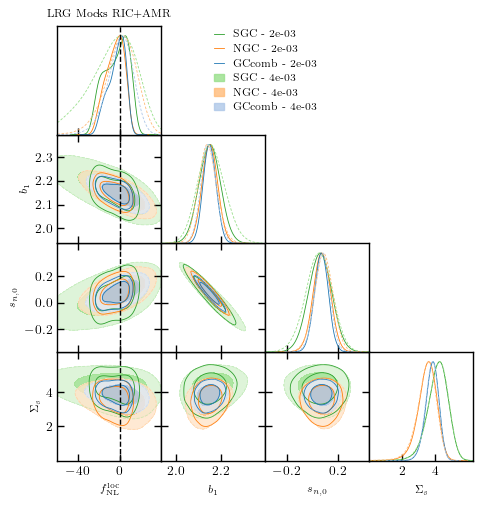

('QSOxQSO', 'SGC', '', 0.001)
('QSOxQSO', 'SGC', '', 0.003)
('QSOxQSO', 'SGC', '', 0.008)
('QSOxQSO', 'SGC', '', 0.002)
('QSOxQSO', 'SGC', 'RIC', 0.001)
('QSOxQSO', 'SGC', 'RIC', 0.003)
('QSOxQSO', 'SGC', 'RIC', 0.008)
('QSOxQSO', 'SGC', 'RIC', 0.002)
('QSOxQSO', 'SGC', 'RIC+AMR', 0.003)
('QSOxQSO', 'SGC', 'RIC+AMR', 0.003)
('QSOxQSO', 'SGC', 'RIC+AMR', 0.008)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


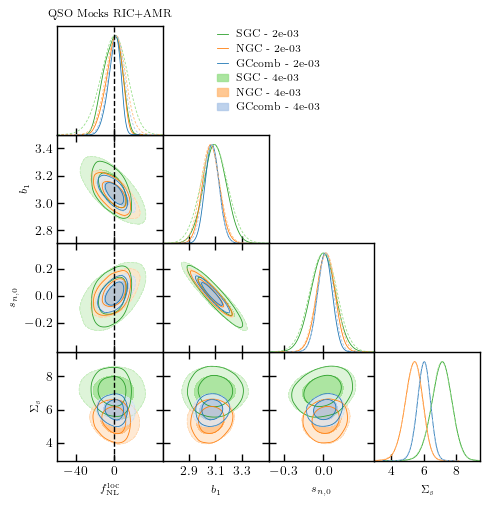

('LRGxQSO', 'SGC', '', 0.001)
('LRGxQSO', 'SGC', '', 0.003)
('LRGxQSO', 'SGC', '', 0.008)
('LRGxQSO', 'SGC', '', 0.002)
('LRGxQSO', 'SGC', 'RIC', 0.001)
('LRGxQSO', 'SGC', 'RIC', 0.003)
('LRGxQSO', 'SGC', 'RIC', 0.008)
('LRGxQSO', 'SGC', 'RIC', 0.002)
('LRGxQSO', 'SGC', 'RIC+AMR', 0.001)
('LRGxQSO', 'SGC', 'RIC+AMR', 0.003)
('LRGxQSO', 'SGC', 'RIC+AMR', 0.008)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


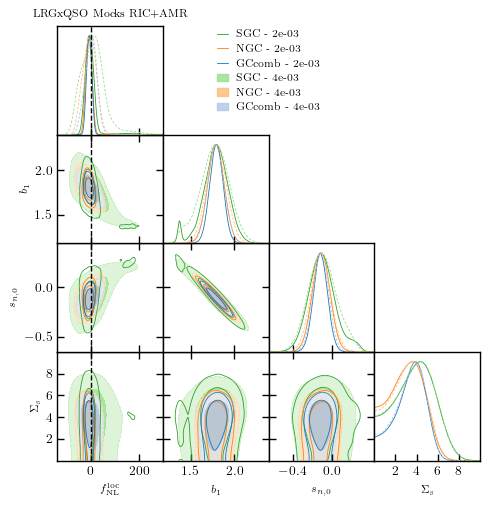

('ELGxELG', 'SGC', '', 0.001)
('ELGxELG', 'SGC', '', 0.003)
('ELGxELG', 'SGC', '', 0.008)
('ELGxELG', 'SGC', '', 0.002)
('ELGxELG', 'SGC', 'RIC', 0.001)
('ELGxELG', 'SGC', 'RIC', 0.003)
('ELGxELG', 'SGC', 'RIC', 0.008)
('ELGxELG', 'SGC', 'RIC', 0.002)
('ELGxELG', 'SGC', 'RIC+AMR', 0.001)
('ELGxELG', 'SGC', 'RIC+AMR', 0.003)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


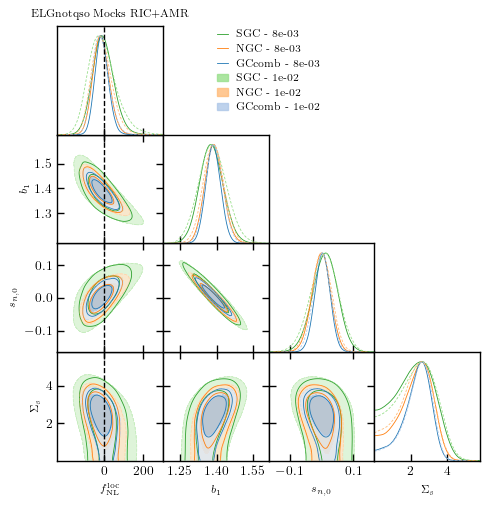

('ELGxELG', 'SGC', 'RIC+AMR', 0.002)
('LRGxELG', 'SGC', '', 0.001)
('LRGxELG', 'SGC', '', 0.003)
('LRGxELG', 'SGC', '', 0.008)
('LRGxELG', 'SGC', '', 0.002)
('LRGxELG', 'SGC', 'RIC', 0.001)
('LRGxELG', 'SGC', 'RIC', 0.003)
('LRGxELG', 'SGC', 'RIC', 0.008)
('LRGxELG', 'SGC', 'RIC', 0.002)
('LRGxELG', 'SGC', 'RIC+AMR', 0.001)
('LRGxELG', 'SGC', 'RIC+AMR', 0.003)
('LRGxELG', 'SGC', 'RIC+AMR', 0.008)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


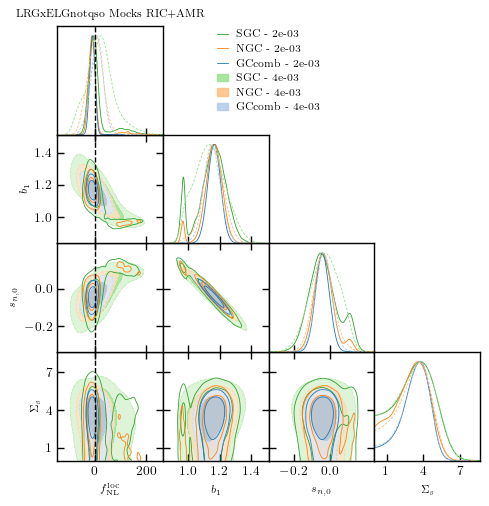

('ELGxQSO', 'SGC', '', 0.001)
('ELGxQSO', 'SGC', '', 0.003)
('ELGxQSO', 'SGC', '', 0.008)
('ELGxQSO', 'SGC', '', 0.002)
('ELGxQSO', 'SGC', 'RIC', 0.001)
('ELGxQSO', 'SGC', 'RIC', 0.003)
('ELGxQSO', 'SGC', 'RIC', 0.008)
('ELGxQSO', 'SGC', 'RIC', 0.002)
('ELGxQSO', 'SGC', 'RIC+AMR', 0.001)
('ELGxQSO', 'SGC', 'RIC+AMR', 0.003)
('ELGxQSO', 'SGC', 'RIC+AMR', 0.008)


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_84164/2430317209.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


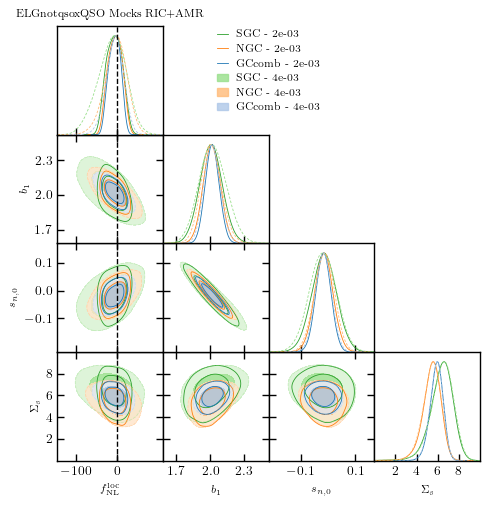

In [113]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for key in ['', 'RIC', 'RIC+AMR']:
        kmin_to_test = [[1e-3, 3e-3], [3e-3, 5e-3], [8e-3, 1e-2], [2e-3, 4e-3]]
        for ii, kmins in enumerate(kmin_to_test):
            try:
                to_display = []
                for kmin in kmins:
                    for region in ['SGC', 'NGC', 'GCcomb']:
                        to_display += [chains[(tracer, region, key, kmin)]]

                from tools import get_getdist_plotter, plot_triangle
                g = get_getdist_plotter(fig_width_inch=5)

                legend_labels = [f'{region} - {kmin:.0e}' for kmin in kmins for region in ['SGC', 'NGC', 'GCcomb']]
                if 'x' in tracer_save:
                    tt1, tt2 = tracer_save.split('x')
                    tt1, tt2 = tt1[:3], tt2[:3]
                    tmp = 'x'.join([tt1, tt2])
                    params = ['fnl_loc', f'{tt2}_{tmp}_ell0.b1', f'{tt1}_{tmp}_ell0x{tt2}_{tmp}_ell0.sn0', f'{tt2}_{tmp}_ell0.sigmas']
                else:
                    tt = tracer_save[:3]
                    params = ['fnl_loc', f'{tt}_ell0.b1', f'{tt}_ell0.sn0', f'{tt}_ell0.sigmas']

                fig = plot_triangle(to_display,  params, legend_labels=legend_labels, 
                                    xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_{s}$'], 
                                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', '#98df8a', '#ffbb78', '#aec7e8',],
                                    filled=[False, False, False, True, True, True],
                                    contour_ls=['-', '-', '-', '--', '--', '--'],  g=g, return_fig=True)

                axs = fig.get_axes()
                for i in range(4):
                    axs[i].axvline(0, ls='--', c='k', lw=1)
                    if tracer_save == 'LRG':
                        axs[i].set_xlim(-60, 40)
                
                #axs[2].axhline(2.151, ls='--', c='k', lw=1)
                axs[3].set_title(f'{tracer_save} Mocks {key}')
                plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
                plt.show()

            except KeyError as e:
                print(e)
                continue

In [114]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    if 'x' in tracer_save:
        tt1, tt2 = tracer_save.split('x')
        tt1, tt2 = tt1[:3], tt2[:3]
        tmp = 'x'.join([tt1, tt2])
        params_to_show = ['fnl_loc', f'{tt2}_{tmp}_ell0.b1']
    else:
        tt = tracer_save[:3]
        params_to_show = ['fnl_loc', f'{tt}_ell0.b1']
        
    quantities = ['argmax', 'mean', 'std', 'interval:1sigma']

    for kmin in [1e-3, 2e-3, 3e-3, 4e-3, 5e-3]:
        try: 
            print(f"Results for {tracer_save=} kmin={kmin:.0e}:")
            for region in ['GCcomb', 'NGC', 'SGC']:
                cc = chains[(tracer, region, 'RIC+AMR', kmin)]
                print(cc.to_stats(params=params_to_show, quantities=quantities, tablefmt="pretty"))
        except KeyError:
            continue
        print("\n")

Results for tracer_save='LRG' kmin=1e-03:
Results for tracer_save='LRG' kmin=2e-03:
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |  1.7   | -3.0  |  8.2  |   +11.0/-5.5    |
| LRG_ell0.b1 | 2.141  | 2.150 | 0.028 |  +0.026/-0.030  |
+-------------+--------+-------+-------+-----------------+
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |  -1.2  | -4.7  |  8.7  |   +10.8/-7.6    |
| LRG_ell0.b1 | 2.144  | 2.151 | 0.034 |  +0.035/-0.033  |
+-------------+--------+-------+-------+-----------------+
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |   5    |  -3   

In [115]:
import numpy as np
from scipy import stats

def tension_asymmetric(mean, sigma_down, sigma_up, fiducial):
    delta = mean - fiducial

    if delta == 0:
        return 0.0, 1.0

    if delta > 0:          # fiducial is below the mean
        sigma_eff = sigma_down
        side = "lower (sigma_down used)"
    else:                  # fiducial is above the mean
        sigma_eff = sigma_up
        side = "upper (sigma_up used)"

    tension  = delta / sigma_eff
    p_value  = 2 * stats.norm.sf(abs(tension))
    return tension, float(p_value) #, side

for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for kmin in [1e-3, 2e-3, 3e-3, 4e-3, 5e-3]:
        print(f"Results for {tracer_save=} kmin={kmin:.0e}:")
        try: 
            for region in ['GCcomb', 'NGC', 'SGC']:
                cc = chains[(tracer, region, 'RIC+AMR', kmin)]
                cc = cc.to_stats(params=['fnl_loc'], quantities=['mean', 'interval:1sigma'], tablefmt="list")[0]
                mean, sigma = cc[0][1], cc[0][2]
                sigma_down, sigma_up = sigma.split('/')
                mean, sigma_down, sigma_up = float(mean), float(sigma_down), float(sigma_up)
                tension, p_value = tension_asymmetric(mean, sigma_down, sigma_up, fiducial=0)
                print(f"{region}: fnl_loc = {mean:.2f} (+{sigma_up:.2f}/-{sigma_down:.2f}), tension = {tension:.2f} sigma, p-value = {p_value:.3f}")
        except KeyError:
            continue
        print("\n")

Results for tracer_save='LRG' kmin=1e-03:
Results for tracer_save='LRG' kmin=2e-03:
GCcomb: fnl_loc = -3.00 (+-5.50/-11.00), tension = 0.55 sigma, p-value = 0.585
NGC: fnl_loc = -4.70 (+-7.60/-10.80), tension = 0.62 sigma, p-value = 0.536
SGC: fnl_loc = -3.00 (+-9.80/-15.40), tension = 0.31 sigma, p-value = 0.760


Results for tracer_save='LRG' kmin=3e-03:
Results for tracer_save='LRG' kmin=4e-03:
GCcomb: fnl_loc = 0.00 (+-11.00/-13.00), tension = 0.00 sigma, p-value = 1.000
NGC: fnl_loc = 1.00 (+-13.00/-17.00), tension = 0.06 sigma, p-value = 0.953
SGC: fnl_loc = -7.00 (+-18.00/-27.00), tension = 0.39 sigma, p-value = 0.697


Results for tracer_save='LRG' kmin=5e-03:
Results for tracer_save='QSO' kmin=1e-03:
GCcomb: fnl_loc = -0.80 (+-3.50/-4.00), tension = 0.23 sigma, p-value = 0.819
NGC: fnl_loc = -0.90 (+-4.30/-4.50), tension = 0.21 sigma, p-value = 0.834
SGC: fnl_loc = -1.20 (+-5.40/-5.30), tension = 0.22 sigma, p-value = 0.824


Results for tracer_save='QSO' kmin=2e-03:
GCcomb: f

## Combined Mean mocks:

In [ ]:
from tools import get_observable_and_likelihood, run_profiler, run_mcmc, plot_observables
from tools import build_total_likelihood

orders = [['LRGxLRG', 'QSOxQSO']]
kmin_tracers = [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3}]

orders += [['LRGxLRG', 'QSOxQSO']]
kmin_tracers += [{'LRGxLRG': 6e-3, 'QSOxQSO': 2e-3}]

orders += [['LRGxQSO', 'QSOxQSO']]
kmin_tracers += [{'LRGxQSO': 2e-3, 'QSOxQSO': 2e-3}]

orders += [['LRGxQSO', 'QSOxQSO']]
kmin_tracers += [{'LRGxQSO': 4e-3, 'QSOxQSO': 2e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 2e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
kmin_tracers += [{'LRGxLRG': 6e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 6e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
kmin_tracers += [{'LRGxLRG': 6e-3, 'QSOxQSO': 4e-3, 'LRGxQSO': 6e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
kmin_tracers += [{'LRGxLRG': 6e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 2e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxQSO']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3, 'ELGxQSO': 4e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3, 'LRGxELG': 4e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3, 'LRGxELG': 4e-3, 'ELGxQSO': 4e-3}]

orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
kmin_tracers += [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3, 'LRGxELG': 4e-3, 'ELGxQSO': 4e-3, 'ELGxELG': 8e-3}]

key = 'RIC+AMR'
region = 'GCcomb'

force_mcmc = True

for (order, kmin_tracer) in zip(orders, kmin_tracers):
    print(order, kmin_tracer)
    obs, lik = {}, {}
    pp, mm = {}, {}
    for tt in order:
        kmin = kmin_tracer[tt]

        # Restrict mocks to k>kmin:
        pp[tt] = mean_mocks[tt][region][key].select(k=(kmin, 1))

        # Finally, it changes nothing, so I decide to keep these quadruopoles.  
        # if tt.split('x')[0] != tt.split('x')[1]:  # cross-correlation
        #     logger.info(f"{tt}: Dropping ell=2 for the cross-correlation to reduce hartlap factor and speed up the fit. (Those data points are very noisy for now...)")
        #     pp[tt] = pp[tt].get(ells=[0])  # only use monopole for cross-correlations

        ww = window[tt][region][key].at.observable.match(pp[tt])
        mm[tt] = [mock.match(pp[tt]) for mock in mocks[tt][region]['RIC+AMR']]   # use 1000 EZmocks

        obs[tt], lik[tt] = get_observable_and_likelihood(pp[tt], ww, mm[tt], tt, zeffs[region], engine='camb', fix_fnl=False, nickname=tt) 

    lik['-'.join(order)] = build_total_likelihood(order, pp, obs, mm, zeffs[region], fiducial)

    profilers[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))] = run_profiler(lik['-'.join(order)])
    #print(profilers[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))].to_stats(tablefmt="pretty"))

    # running chains can be long ... 
    key_tag = 'noIC' if key == '' else key

    dir_output = f'{dir_chains}/samples_{'-'.join(order)}_nmean_{nmean}_{region}_{key_tag}_kmin-{'-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order])}/'
    from desilike.samples import MCSamples
    if not os.path.exists(dir_output) or force_mcmc:  # avoid re-running if chain already exists
        sampler = run_mcmc(lik['-'.join(order)], dir_output=dir_output, max_steps=40000, check_every=20000)
        chains[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))] =  MCSamples.concatenate([cc.remove_burnin(burnin)[::thin] for cc in sampler.chains])
    else:
        fns = sorted(Path(dir_output).glob('samples_*.h5'))
        chains[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))] = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin)[::thin] for fn in fns])
    

['LRGxLRG', 'QSOxQSO'] {'LRGxLRG': 0.004, 'QSOxQSO': 0.002}
['LRGxLRG', 'QSOxQSO'] {'LRGxLRG': 0.006, 'QSOxQSO': 0.002}
['LRGxQSO', 'QSOxQSO'] {'LRGxQSO': 0.002, 'QSOxQSO': 0.002}
['LRGxQSO', 'QSOxQSO'] {'LRGxQSO': 0.004, 'QSOxQSO': 0.002}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] {'LRGxLRG': 0.004, 'QSOxQSO': 0.002, 'LRGxQSO': 0.002}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] {'LRGxLRG': 0.004, 'QSOxQSO': 0.002, 'LRGxQSO': 0.004}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] {'LRGxLRG': 0.006, 'QSOxQSO': 0.002, 'LRGxQSO': 0.006}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] {'LRGxLRG': 0.006, 'QSOxQSO': 0.004, 'LRGxQSO': 0.006}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] {'LRGxLRG': 0.006, 'QSOxQSO': 0.002, 'LRGxQSO': 0.002}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxQSO'] {'LRGxLRG': 0.004, 'QSOxQSO': 0.002, 'LRGxQSO': 0.004, 'ELGxQSO': 0.004}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG'] {'LRGxLRG': 0.004, 'QSOxQSO': 0.002, 'LRGxQSO': 0.004, 'LRGxELG': 0.004}
['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO'] {'LRGxLRG': 0.004, 'QSO

+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |  0.  | 16  |     +17/-14     |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | -0.1 | 6.5 |    +7.3/-5.5    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |  -5  | 10. |     +11/-11     |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.4  | 5.9 |    +6.6/-5.1    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_3649/1287999226.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/L+Q+LxQ_mocks_mcmc_kmin_{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


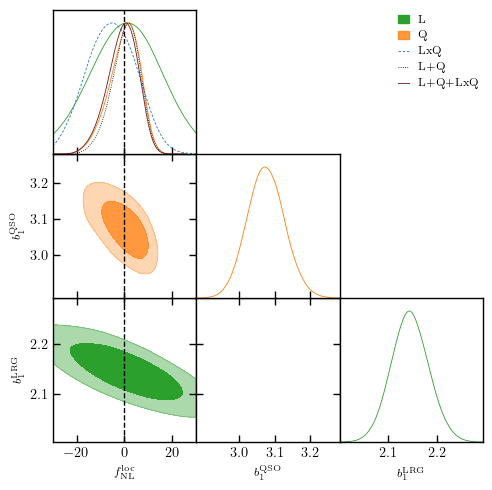

In [144]:
kmin_lrg = 6e-3
kmin_qso = 2e-3
kmin_lrgxqso = 2e-3

keys = [('LRGxLRG', 'GCcomb', 'RIC+AMR', kmin_lrg), 
        ('QSOxQSO', 'GCcomb', 'RIC+AMR', kmin_qso), 
        ('LRGxQSO', 'GCcomb', 'RIC+AMR', kmin_lrgxqso), 
        ('LRGxLRG-QSOxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}'),
        ('LRGxLRG-QSOxQSO-LRGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}')]
to_display = [chains[key] for key in keys]

for cc in to_display:
    print(cc.to_stats(params=['fnl_loc'], quantities=['mean', 'std', 'interval:1sigma'], tablefmt="pretty"))

g = get_getdist_plotter(fig_width_inch=5)

legend_labels = ['L', 'Q', 'LxQ', 'L+Q', 'L+Q+LxQ']
params = ['fnl_loc', 'QSO_ell0.b1', 'LRG_ell0.b1']
xlabels = [r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm LRG}$']

fig = plot_triangle(to_display,  params, legend_labels=legend_labels, xlabels=xlabels, 
                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', "#000000", "#731717",],
                    filled=[True, True, False, False, False],
                    contour_ls=['-', '-', '--', ':', '-'],  g=g, return_fig=True)

axs = fig.get_axes()
for i in range(3): 
    axs[i].axvline(0, ls='--', c='k', lw=1)
    axs[i].set_xlim(-30, 30)

#axs[2].axhline(2.151, ls='--', c='k', lw=1)
plt.savefig(f'fig/L+Q+LxQ_mocks_mcmc_kmin_{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}.png', dpi=400)

plt.show()

In [145]:
kmin_lrg = 6e-3
kmin_qso = 2e-3
print(chains[('LRGxLRG-QSOxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}')].to_stats(tablefmt="pretty"))

+-------------------------+--------+-------+--------+-------+-----------------+-----------------+
|                         | argmax | mean  | median |  std  | quantile:1sigma | interval:1sigma |
+-------------------------+--------+-------+--------+-------+-----------------+-----------------+
|   LRG_LRGxLRG_ell0.b1   | 2.143  | 2.145 | 2.144  | 0.028 |  +0.028/-0.028  |  +0.028/-0.028  |
| LRG_LRGxLRG_ell0.sigmas |  3.77  | 3.79  |  3.82  | 0.41  |   +0.40/-0.40   |   +0.43/-0.37   |
|  LRG_LRGxLRG_ell0.sn0   | 0.082  | 0.077 | 0.077  | 0.056 |  +0.056/-0.056  |  +0.057/-0.055  |
|         fnl_loc         |  2.2   |  0.4  |  0.8   |  5.9  |    +5.9/-6.0    |    +6.6/-5.1    |
|   QSO_QSOxQSO_ell0.b1   | 3.071  | 3.073 | 3.073  | 0.052 |  +0.052/-0.052  |  +0.052/-0.051  |
| QSO_QSOxQSO_ell0.sigmas |  5.96  | 6.01  |  6.01  | 0.41  |   +0.41/-0.41   |   +0.42/-0.40   |
|  QSO_QSOxQSO_ell0.sn0   | 0.007  | 0.012 | 0.012  | 0.056 |  +0.057/-0.056  |  +0.059/-0.054  |
+-------------------

+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.5  | 5.8 |    +6.5/-5.0    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.3  | 6.0 |    +6.8/-4.9    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.3  | 6.0 |    +6.7/-5.0    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | -2.7 | 8.0 |    +9.6/-6.7    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |

IndexError: index 3 is out of bounds for axis 0 with size 1

/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


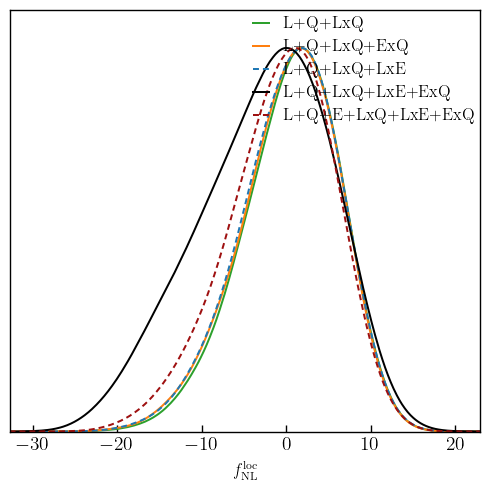

In [146]:
kmin_lrg = 4e-3
kmin_qso = 2e-3
kmin_elgxelg = 8e-3
kmin_lrgxqso = 4e-3
kmin_lrgxelg = 4e-3
kmin_elgxqso = 4e-3

keys = [('LRGxLRG-QSOxQSO-LRGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}'),
        ('LRGxLRG-QSOxQSO-LRGxQSO-ELGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_elgxqso:1.0e}'),
        ('LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_lrgxelg:1.0e}'),
        ('LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_lrgxelg:1.0e}-{kmin_elgxqso:1.0e}'),
        ('LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_elgxelg:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_lrgxelg:1.0e}-{kmin_elgxqso:1.0e}')
        ]
to_display = [chains[key] for key in keys]

for cc in to_display:
    print(cc.to_stats(params=['fnl_loc'], quantities=['mean', 'std', 'interval:1sigma'], tablefmt="pretty"))

g = get_getdist_plotter(fig_width_inch=5)

legend_labels = ['L+Q+LxQ', 'L+Q+LxQ+ExQ', 'L+Q+LxQ+LxE', 'L+Q+LxQ+LxE+ExQ', 'L+Q+E+LxQ+LxE+ExQ']
params = ['fnl_loc', 'QSO_ell0.b1', 'LRG_ell0.b1', 'ELG_ell0.b1']
xlabels = [r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm LRG}$', r'$b_1^{\rm ELG}$']

fig = plot_triangle(to_display,  params, legend_labels=legend_labels, xlabels=xlabels, 
                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', "#000000", "#9E1010"],
                    filled=[True, True, False, False, False],
                    contour_ls=['-', '-', '--', '-', '--'],  g=g, return_fig=True)

axs = fig.get_axes()
for i in range(4): 
    axs[i].axvline(0, ls='--', c='k', lw=1)
    axs[i].set_xlim(-25, 25)

#axs[2].axhline(2.151, ls='--', c='k', lw=1)
plt.savefig(f'fig/L+Q+LxQ+LxE+ExQ_mocks_mcmc_kmin_3e-3-5e-3.png', dpi=400)

plt.show()

## Create a summary latex table:

In [147]:
import pandas as pd
import re


def _pretty_tracer_label(tracer):
    """Simplify tracer names: LRGxLRG -> L, LRGxQSO -> LxQ, and combined keys with '-' -> '+'."""
    tracer = str(tracer).strip()
    short = {"LRG": "L", "QSO": "Q", "ELG": "E"}
    if "-" in tracer:
        return " + ".join(_pretty_tracer_label(tt.strip()) for tt in tracer.split("-"))
    if "x" in tracer:
        a, b = [t.strip() for t in tracer.split("x", 1)]
        a_s = short.get(a, a)
        b_s = short.get(b, b)
        return a_s if a_s == b_s else f"{a_s}x{b_s}"
    return short.get(tracer, tracer)


def _parse_configuration(cfg):
    # Expected format from _format_chain_key:
    # "{tracer} | {region} | {window_key} | kmin={kmin_str}"
    m = re.match(r"^(.*?) \| (.*?) \| (.*?) \| kmin=(.*)$", str(cfg))
    if m is None:
        return None
    tracer, region, _window_key, kmin = m.groups()  # drop window_key (RIC+AMR column)
    return _pretty_tracer_label(tracer), region, kmin


def _translator(param):
    """Translate parameter names to LaTeX-friendly labels."""
    # Add more translations as needed
    translations = {
        "fnl_loc": r"$f_{\rm NL}^{\rm loc}$",
        "LRG_ell0.b1": r"$b_1^{\rm LRG}$",
        "QSO_ell0.b1": r"$b_1^{\rm QSO}$",
        "ELG_ell0.b1": r"$b_1^{\rm ELG}$",
        }
    return translations.get(param, param)


def _latex_kmin_label(kmin_label):
    """Format long kmin labels for LaTeX table cells."""
    kmin_label = str(kmin_label)
    parts = kmin_label.split("-")

    if len(parts) > 3:
        mid = len(parts) // 2
        line1 = "-".join(parts[:mid])
        line2 = "-".join(parts[mid:])
        return r"\shortstack[l]{" + line1 + r" \\ " + line2 + "}"

    if "-" in kmin_label:
        return rf"${kmin_label}$"

    return rf"${kmin_label}$"


def _latex_tracer_label(tracer_label):
    """Format long tracer labels for LaTeX table cells."""
    tracer_label = str(tracer_label)

    parts = [p.strip() for p in tracer_label.split(" + ")]
    if len(parts) > 3:
        mid = len(parts) // 2
        line1 = " + ".join(parts[:mid])
        line2 = " + ".join(parts[mid:])
        return r"\shortstack[l]{" + line1 + r" \\ " + line2 + "}"

    return tracer_label


def mcmc_to_latex_table(self, *args, **kwargs):
    # Apply custom rendering only to this specific table shape
    if "Configuration" not in self.columns:
        return pd.DataFrame.to_latex(self, *args, **kwargs)

    parsed = [_parse_configuration(v) for v in self["Configuration"].tolist()]
    if any(p is None for p in parsed):
        return pd.DataFrame.to_latex(self, *args, **kwargs)

    param_cols = [c for c in self.columns if c != "Configuration"]

    # Build row records with parsed fields
    records = []
    for i, (tracer_label, region_label, kmin_label) in enumerate(parsed):
        row_vals = [self.iloc[i][p] for p in param_cols]
        records.append((tracer_label, region_label, kmin_label, row_vals))

    # Group hierarchy: tracer -> region -> rows (preserve insertion order)
    grouped = {}
    tracer_order = []
    for tracer_label, region_label, kmin_label, row_vals in records:
        if tracer_label not in grouped:
            grouped[tracer_label] = {"regions": {}, "region_order": [], "nrows": 0}
            tracer_order.append(tracer_label)
        if region_label not in grouped[tracer_label]["regions"]:
            grouped[tracer_label]["regions"][region_label] = []
            grouped[tracer_label]["region_order"].append(region_label)
        grouped[tracer_label]["regions"][region_label].append((kmin_label, row_vals))
        grouped[tracer_label]["nrows"] += 1

    # Build LaTeX manually
    colfmt = "l l l" + " c" * len(param_cols)
    lines = []
    lines.append(r"\begin{tabular}{" + colfmt + "}")
    lines.append(r"\hline")
    header = ["Tracer", "Region", r"$k_{\rm min}$"] +[_translator(p) for p in param_cols]
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\hline")

    for tracer_label in tracer_order:
        tracer_block = grouped[tracer_label]
        tracer_nrows = tracer_block["nrows"]
        first_row_for_tracer = True
        tracer_label_latex = _latex_tracer_label(tracer_label)

        for region_label in tracer_block["region_order"]:
            region_rows = tracer_block["regions"][region_label]
            region_nrows = len(region_rows)

            for j, (kmin_label, row_vals) in enumerate(region_rows):
                tracer_cell = (
                    rf"\multirow{{{tracer_nrows}}}{{*}}{{{tracer_label_latex}}}"
                    if first_row_for_tracer and tracer_nrows > 1
                    else (tracer_label_latex if first_row_for_tracer else "")
                )
                region_cell = (
                    rf"\multirow{{{region_nrows}}}{{*}}{{{region_label}}}"
                    if j == 0 and region_nrows > 1
                    else (region_label if j == 0 else "")
                )

                kmin_cell = _latex_kmin_label(kmin_label)
                vals = [tracer_cell, region_cell, kmin_cell] + [str(v) for v in row_vals]
                lines.append(" & ".join(vals) + r" \\")
                first_row_for_tracer = False

        lines.append(r"\hline")

    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def _format_chain_key(chain_key):
    tracer, region, window_key, kmin = chain_key
    kmin_str = f"{kmin:.0e}" if isinstance(kmin, float) else str(kmin)
    return f"{tracer} | {region} | {window_key} | kmin={kmin_str}"


def _format_param_value(chain, param):
    """Return mean ± std from MCSamples.to_stats(), or '--' if unavailable."""
    try:
        row = chain.to_stats(params=[param], quantities=["mean", "std"], tablefmt="list")[0][0]
        mean = float(row[1])
        stdv = float(row[2])
        return f"${mean:.3f} \\pm {stdv:.3f}$"
    except Exception:
        return "--"

In [148]:
def _kmin_sort_key(kmin):
    """Sort helper for kmin values (float or 'a-b-c' string)."""
    if isinstance(kmin, (int, float)):
        return (float(kmin),)
    s = str(kmin).strip()
    if "-" in s:
        out = []
        for x in s.split("-"):
            try:
                out.append(float(x))
            except ValueError:
                out.append(float("inf"))
        return tuple(out)
    try:
        return (float(s),)
    except ValueError:
        return (float("inf"),)


def _chain_sort_key(chain_key):
    """Custom order"""
    tracer, region, window_key, kmin = chain_key

    label = _pretty_tracer_label(tracer).replace(" ", "")
    preferred = {
        "L": 0,
        "E": 1,
        "Q": 2,
        "LxQ": 3,
        "LxE": 4,
        "ExQ": 5,
        "L+Q": 6,
        "LxQ+Q": 7,
        "L+Q+LxQ": 8,
    }

    # Fallback for any non-explicit tracer combination
    rank = preferred.get(label, 100)
    region_order = {"GCcomb": 0, "NGC": 1, "SGC": 2}

    return (
        rank,
        label,  # stable fallback among non-listed labels
        region_order.get(region, 99),
        str(window_key),
        _kmin_sort_key(kmin),
    )

In [149]:
# Choose parameters to display (edit this list)
selected_params = ["fnl_loc", "LRG_ell0.b1", "ELG_ell0.b1", "QSO_ell0.b1"]

# Optional: restrict to a subset of chains. Keep None to include all.
# selected_chain_keys = None  # e.g. [("LRGxLRG", "GCcomb", "RIC+AMR", 0.004), ...]
selected_chain_keys = [ck for ck in chains.keys() if ck[1] == "GCcomb"]

# Optional output file (set to None to skip writing)
latex_output = 'tables/holi-v3-mcmc.tex'  # e.g. "fig/mcmc_summary_table.tex"

chain_keys = selected_chain_keys if selected_chain_keys is not None else sorted(chains.keys(), key=_chain_sort_key)

rows = []
for ck in chain_keys:
    row = {"Configuration": _format_chain_key(ck)}
    for param in selected_params:
        row[param] = _format_param_value(chains[ck], param)
    rows.append(row)

latex_table = mcmc_to_latex_table(pd.DataFrame(rows), index=False, escape=False, column_format="l" + "c" * len(selected_params))
print(latex_table)

if latex_output is not None:
    with open(latex_output, "w") as f:
        f.write(latex_table)
    print(f"Saved LaTeX table to: {latex_output}")

\begin{tabular}{l l l c c c c}
\hline
Tracer & Region & $k_{\rm min}$ & $f_{\rm NL}^{\rm loc}$ & $b_1^{\rm LRG}$ & $b_1^{\rm ELG}$ & $b_1^{\rm QSO}$ \\
\hline
\multirow{3}{*}{L} & \multirow{3}{*}{GCcomb} & $2e-03$ & $-3.000 \pm 8.200$ & $2.150 \pm 0.028$ & -- & -- \\
 &  & $4e-03$ & $0.000 \pm 12.000$ & $2.145 \pm 0.034$ & -- & -- \\
 &  & $6e-03$ & $0.000 \pm 16.000$ & $2.145 \pm 0.038$ & -- & -- \\
\hline
\multirow{3}{*}{Q} & \multirow{3}{*}{GCcomb} & $1e-03$ & $-0.800 \pm 3.500$ & -- & -- & $3.082 \pm 0.045$ \\
 &  & $2e-03$ & $-0.100 \pm 6.500$ & -- & -- & $3.075 \pm 0.052$ \\
 &  & $4e-03$ & $1.900 \pm 8.400$ & -- & -- & $3.067 \pm 0.057$ \\
\hline
\multirow{3}{*}{LxQ} & \multirow{3}{*}{GCcomb} & $2e-03$ & $-5.000 \pm 10.000$ & -- & -- & -- \\
 &  & $4e-03$ & $1.000 \pm 24.000$ & -- & -- & -- \\
 &  & $6e-03$ & $0.000 \pm 25.000$ & -- & -- & -- \\
\hline
\multirow{2}{*}{E} & \multirow{2}{*}{GCcomb} & $8e-03$ & $-11.000 \pm 34.000$ & -- & $1.387 \pm 0.031$ & -- \\
 &  & $1e-02$ & $

# Fit each individual mocks:

In [4]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

from tools import run_profiling_one_mock


def load_all_profiles(mocks_dir):
    """
    Load all profile .npy files from the holi-v3-altmtl/mock* directories
    and organize them in a nested dictionary structure.
    
    Handles filenames with optional suffixes:
    - bestfit_{tracer}_{region}_{cov_type}_kmin-{kmin}.npy
    - bestfit_{tracer}_{region}_{cov_type}_kmin-{kmin}_{any_suffix}.npy
    
    Returns:
        profiles: dict with structure {tracer: {region: {cov_type: {kmin: {suffix: {imock: array}}}}}}
    """
    import re
    from pathlib import Path
    from collections import defaultdict

    base_dir = Path(mocks_dir.replace('summary_statistics', 'profiles')) / 'holi-v3-altmtl'
    
    profiles = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))))
    
    pattern = r'bestfit_(.+?)_((?:NGC|SGC|GCcomb))_(analytical_cov|mock_cov)_kmin-([0-9e\-\.]+)(_.*)?\.npy'
    
    mock_dirs = sorted(base_dir.glob('mock*'), key=lambda x: int(x.name.replace('mock', '')))
    
    for mock_dir in mock_dirs:
        if not mock_dir.is_dir():
            continue
        
        imock = int(mock_dir.name.replace('mock', ''))
        
        for npy_file in sorted(mock_dir.glob('bestfit_*.npy')):
            match = re.match(pattern, npy_file.name)
            if match:
                tracer, region, cov_type, kmin, suffix = match.groups()
                #try:
                #    kmin = float(kmin)
                #except ValueError:
                #    pass  # keep kmin as string for combined-tracer cases (e.g. '4e-03-2e-03')
                suffix = suffix if suffix else ''
                
                profiles[tracer][region][cov_type][kmin][suffix][imock] = np.load(str(npy_file))
    
    profiles = {k: {k2: {k3: {k4: {k5: dict(v5) for k5, v5 in v4.items()} for k4, v4 in v3.items()} for k3, v3 in v2.items()} for k2, v2 in v.items()} 
                for k, v in profiles.items()}
    
    return profiles


def summary_profiles(profiles):
    """ Generate a summary DataFrame of the loaded profiles, showing the number of mocks and range of mock 
        indices for each tracer, region, covariance type, kmin, and suffix.
    """
    import pandas as pd
    summary_data = []
    for tracer in sorted(profiles):
        for region in sorted(profiles[tracer].keys()):
            for cov_type in sorted(profiles[tracer][region].keys()):
                for kmin in sorted(profiles[tracer][region][cov_type].keys()):
                    for suffix in sorted(profiles[tracer][region][cov_type][kmin].keys()):
                        n_mocks = len(profiles[tracer][region][cov_type][kmin][suffix])
                        mock_indices = sorted(profiles[tracer][region][cov_type][kmin][suffix].keys())
                        summary_data.append({
                            'Tracer': tracer,
                            'Region': region,
                            'Cov_Type': cov_type,
                            'Kmin': kmin,
                            'Suffix': suffix if suffix else '(none)',
                            'N_Mocks': n_mocks,
                            'Mock_Range': f"{min(mock_indices)}-{max(mock_indices)}"
                        })

    summary_df = pd.DataFrame(summary_data)

    return summary_df

def diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, nmocks, xlim_fnl=None, xlim_fnlerr=None, fn_fig=None):
    from scipy.stats import norm, chi2

    labels = {'LRGxLRG': 'L', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'ELGxELG': 'E', 'LRGxELG': 'LxE', 'ELGxQSO': 'ExQ',
              'LRGxLRG-LRGxQSO-QSOxQSO': 'L+Q+LxQ', 
              'LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO': 'L+Q+LxQ+ExQ',
              'LRGxLRG-LRGxQSO-QSOxQSO-LRGxELG': 'L+Q+LxQ+LxE',
              'LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO-LRGxELG-ELGxELG': 'L+Q+E+LxQ+LxE+ExQ'}

    plt.figure(figsize=(10, 3))
    plt.subplot(131)
    if xlim_fnl: plt.xlim(-xlim_fnl, xlim_fnl)
    for tracer in tracers_to_plot:
        prof = profiles[tracer][region]
        plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 1000)
        mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)])
        plt.plot(x, norm.pdf(x, mu, std), c='k', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
    plt.axvline(0, ls=':', c='gray', alpha=1, zorder=0)
    plt.legend(loc='upper right', ncol=1)
    plt.xlabel('bestfit')

    plt.subplot(132)
    if xlim_fnlerr: plt.xlim(0, xlim_fnlerr)
    for tracer in tracers_to_plot:
        prof = profiles[tracer][region]
        plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 1000)
        mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)])
        plt.plot(x, norm.pdf(x, mu, std), c='k', ls='--', label=f'{mu:2.2f}', zorder=0)
    plt.legend(loc='upper right', ncol=1)
    plt.xlabel('error')

    plt.subplot(133)
    ndofs = []
    for tracer in tracers_to_plot:
        prof = profiles[tracer][region]
        idx_logpost = np.where(prof['mock_cov'][kmin][extra_fn][0][:,0] == 'logposterior')[0][0]
        nparams = float(np.sum(prof['mock_cov'][kmin][extra_fn][0][:,3] > ''))
        if "-" not in tracer:  
            nbins = mocks[tracer][0].select(k=(float(kmin), 1)).size    
        else:
            nbins = 0
            for tt, kk in zip(tracer.split("-"), kmin.split("-")):
                if np.unique(tt.split("x")).size > 1: 
                    nbins += mocks[tt][0].get(ells=[0]).select(k=(float(kk), 1)).size
                else:
                    nbins += mocks[tt][0].select(k=(float(kk), 1)).size
        ndof = nbins - nparams
        ndofs.append(ndof)

        from lsstypes.utils import get_percival2014_factor
        percival = get_percival2014_factor(len(mocks['LRGxLRG']) - 1, nbins, nparams)
        print(f"{tracer}: nbins={nbins}, nparams={nparams}, ndof={ndof}, percival={percival:.3f}, {percival / ndof:.3f}")

        red_chi2 = [-2*float(prof['mock_cov'][kmin][extra_fn][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

        plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

    for ndof in np.unique(ndofs):
        x = np.linspace(0.4, 2.0, 500)
        plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='k', zorder=0)
    plt.legend()    
    plt.xlabel(r'$\chi^2_{\rm{red}}$')

    plt.tight_layout()
    if fn_fig: plt.savefig(fn_fig, dpi=400)
    plt.show()


In [5]:
## CURRENT STORE PROFILE:

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

summary_df = summary_profiles(profiles)
display(summary_df)

,Tracer,Region,Cov_Type,Kmin,Suffix,N_Mocks,Mock_Range
0,ELGxELG,GCcomb,mock_cov,0.003,_RIC+AMR,50,0-49
1,ELGxELG,GCcomb,mock_cov,0.005,_RIC+AMR,50,0-49
2,ELGxQSO,GCcomb,mock_cov,0.003,_RIC+AMR,50,0-49
3,ELGxQSO,GCcomb,mock_cov,0.005,_RIC+AMR,50,0-49
4,ELGxQSO,GCcomb,mock_cov,2e-03,_RIC+AMR,50,0-49
...,...,...,...,...,...,...,...
67,QSOxQSO,SGC,mock_cov,0.003,_RIC+AMR,100,0-99
68,QSOxQSO,SGC,mock_cov,0.005,_RIC+AMR,100,0-99
69,QSOxQSO,SGC,mock_cov,2e-03,_RIC+AMR,200,0-199
70,QSOxQSO,SGC,mock_cov,3e-03,_RIC+AMR,200,0-199


In [6]:
region = 'GCcomb'

fiducial = propose_fiducial(kmin=1e-3, region=region)

tracers_to_read = ['LRG', 'QSO', 'LRGxQSO'] #['LRG', 'QSO', 'LRGxQSO', 'ELGnotqso', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

#tracers_to_read = ['LRGxELGnotqso', 'ELGnotqsoxQSO']

non_fiducial_binning = False  # test for hartlap factor ... 

window_extra = 'RIC+AMR'
extra_fn = '_' + window_extra if window_extra else ''

if non_fiducial_binning:
    kpivot=[1e-2]
    nrebin=[2]
    extra_fn += '_other_binning'
else:
    kpivot=[1e-2, 2e-2]
    nrebin=[2,2]

pks, windows, covs, zeffs, mocks = {}, {}, {}, {}, {}
alternative_mocks = {}
for tt in tracers_to_read:
    tmp = 'x'.join([tt[:3], tt[:3]]) if 'x' not in tt else tt.replace('notqso', '')
    print(f"Loading data for {tt} ({tmp}) with extra_fn={extra_fn}...")
    pks[tmp], windows[tmp], covs[tmp], zeffs[tmp], mocks[tmp] = load_data(data_dir, mocks_dir, tt, fiducial, window_extra=window_extra,
                                                                          kpivot=kpivot, nrebin=nrebin)
    
    if 'ELG' in tt:
        weight_type_mocks = {'ELGnotqso': 'default-fkp-oqe-wsys-imlin',
                             'LRGxELGnotqso': 'default-fkp-oqexdefault-fkp-oqe-wsys-imlin',
                             'ELGnotqsoxQSO': 'default-fkp-oqe-wsys-imlinxdefault-fkp-oqe'}[tt]
        
        alternative_mocks[tmp] = load_data(data_dir, mocks_dir, tt, fiducial, window_extra=window_extra, weight_type_mocks=weight_type_mocks,
                                           kpivot=kpivot, nrebin=nrebin, nmocks=50)[-1]
        
    else: 
        alternative_mocks[tmp] = None

Loading data for LRG (LRGxLRG) with extra_fn=_RIC+AMR...
Loading data for QSO (QSOxQSO) with extra_fn=_RIC+AMR...
Loading data for LRGxQSO (LRGxQSO) with extra_fn=_RIC+AMR...


In [ ]:
# Do you want to rerun the profiling even if the output file already exists?
force_profiling = False
# Save the bestfit plot?
save_plot = False


# tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO']
# kmin = [{'LRGxLRG': 2e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 2e-3}, {'LRGxLRG': 3e-3, 'QSOxQSO': 3e-3, 'LRGxQSO': 3e-3}, {'LRGxLRG': 4e-3, 'QSOxQSO': 4e-3, 'LRGxQSO': 4e-3}]

#tracers = ['QSOxQSO']
#kmin = [{'QSOxQSO': 2e-3}, {'QSOxQSO': 3e-3}, {'QSOxQSO': 4e-3}]

tracers = ['LRGxLRG-QSOxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO']
kmin = [{'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 4e-3}, {'LRGxLRG': 4e-3, 'QSOxQSO': 2e-3, 'LRGxQSO': 2e-3}]

# tracers = ['LRGxELG', 'ELGxQSO']
# kmin = [{'LRGxELG': 2e-3, 'ELGxQSO': 2e-3}, {'LRGxELG': 4e-3, 'ELGxQSO': 4e-3}, {'LRGxELG': 6e-3, 'ELGxQSO': 6e-3}]

nmocks = 100

analytical_covariances = [False, True][:1]
# Finally no, Keept it!
# # Should be True if combining multiple tracers ! 
# if sum(['-' in tt for tt in tracers]) >= 1:
#     print('DO NOT INCLUDE ell=2 in the cross-correlation')
#     drop_ell2_cross = True
# else:
#     drop_ell2_cross = False
drop_ell2_cross = False

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

base_dir = mocks_dir.replace('summary_statistics', 'profiles') + f"/holi-v3-altmtl/"

with ProcessPoolExecutor(4) as executor:
    list(tqdm.tqdm(
        executor.map(run_profiling_one_mock,
                    [mocks] * len(jobs),
                    [windows] * len(jobs),
                    [covs] * len(jobs),
                    [t       for t, _, _, _ in jobs],
                    [region] * len(jobs),
                    [i       for _, i, _, _ in jobs],
                    [alternative_mocks] * len(jobs),
                    [kk      for _, _, kk, _ in jobs],
                    [drop_ell2_cross] * len(jobs),
                    [ac      for _, _, _, ac in jobs],
                    [force_profiling] * len(jobs),
                    [base_dir] * len(jobs),
                    [fiducial] * len(jobs), 
                    [extra_fn] * len(jobs),
                    [False] * len(jobs),  # return_profiles
                    [save_plot] * len(jobs),
                    ),
        total=len(jobs), desc='Profiling mocks'))


# # Sequential fallback (npool=1):
# for t, i, kk, ac in tqdm.tqdm(jobs):
#     profiler = run_profiling_one_mock(mocks, windows, covs, t, region=region, imock=i, alternative_mocks=alternative_mocks, drop_ell2_cross=drop_ell2_cross,
#                            kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
#                            base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiles=True, save_plot=(i % 10 == 0))
#     if i % 10 == 0:
#        print(profiles.to_stats(tablefmt="pretty"))

400 jobs to run


Profiling mocks:   0%|          | 0/400 [00:20<?, ?it/s]


KeyError: "Variable 'LRG_ell2.sigmas' not found"

In [ ]:
# for t, i, kk, ac in tqdm.tqdm(jobs):
#     profiler = run_profiling_one_mock(mocks, windows, covs, t, region=region, imock=i, alternative_mocks=alternative_mocks, drop_ell2_cross=drop_ell2_cross,
#                            kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
#                            base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiles=True, save_plot=False)

100%|██████████| 400/400 [1:20:13<00:00, 12.03s/it]


In [30]:
# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

summary_df = summary_profiles(profiles)
display(summary_df)

,Tracer,Region,Cov_Type,Kmin,Suffix,N_Mocks,Mock_Range
0,ELGxELG,GCcomb,mock_cov,0.003,_RIC+AMR,50,0-49
1,ELGxELG,GCcomb,mock_cov,0.005,_RIC+AMR,50,0-49
2,ELGxQSO,GCcomb,mock_cov,0.003,_RIC+AMR,50,0-49
3,ELGxQSO,GCcomb,mock_cov,0.005,_RIC+AMR,50,0-49
4,ELGxQSO,GCcomb,mock_cov,2e-03,_RIC+AMR,50,0-49
...,...,...,...,...,...,...,...
70,QSOxQSO,SGC,mock_cov,0.003,_RIC+AMR,100,0-99
71,QSOxQSO,SGC,mock_cov,0.005,_RIC+AMR,100,0-99
72,QSOxQSO,SGC,mock_cov,2e-03,_RIC+AMR,200,0-199
73,QSOxQSO,SGC,mock_cov,3e-03,_RIC+AMR,200,0-199


QSOxQSO: nbins=42, nparams=4.0, ndof=38.0, percival=1.034, 0.027


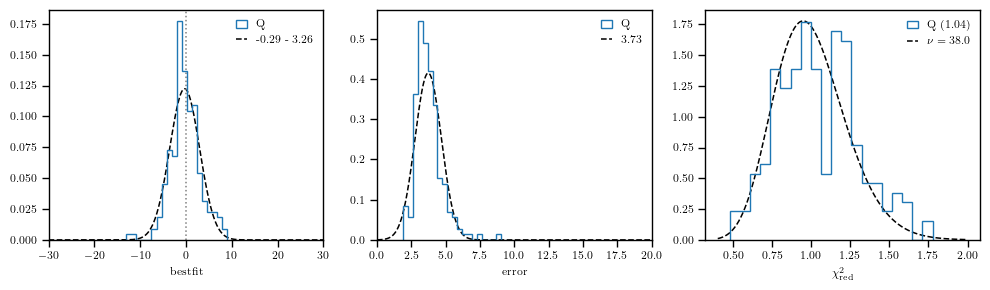

LRGxLRG: nbins=39, nparams=4.0, ndof=35.0, percival=1.031, 0.029
QSOxQSO: nbins=39, nparams=4.0, ndof=35.0, percival=1.031, 0.029
LRGxQSO: nbins=39, nparams=4.0, ndof=35.0, percival=1.031, 0.029


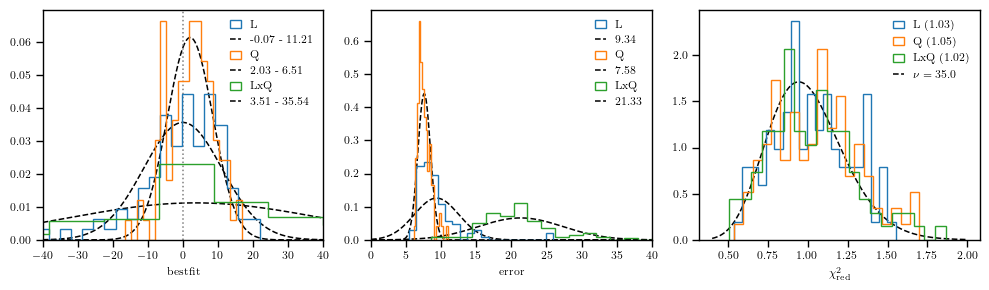

In [41]:
tracers_to_plot = ['QSOxQSO']
region = 'GCcomb' 
kmin = '0.001'
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, 200, xlim_fnl=30, xlim_fnlerr=20, fn_fig='fig/one-by-one_diagnostic_qso-kmin-{kmin}.png')

tracers_to_plot = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO']
kmin = '0.003'
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, 100, xlim_fnl=40, xlim_fnlerr=40, fn_fig='fig/one-by-one_diagnostic_lrg-qso-kmin-{kmin}.png')

# tracers_to_plot = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO']
# kmin = '0.003'
# extra_fn = '_RIC+AMR'
# diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, 200, xlim_fnl=40, xlim_fnlerr=40, fn_fig='fig/one-by-one_diagnostic_lrg-qso-kmin-{kmin}.png')

# tracers_to_plot = ['LRGxLRG', 'LRGxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO']
# kmin = '0.005'
# extra_fn = '_RIC+AMR'
# diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, 200, xlim_fnl=50, xlim_fnlerr=40, fn_fig='fig/one-by-one_diagnostic_lrg-qso-kmin-{kmin}.png')

IndexError: index 3 is out of bounds for axis 0 with size 3

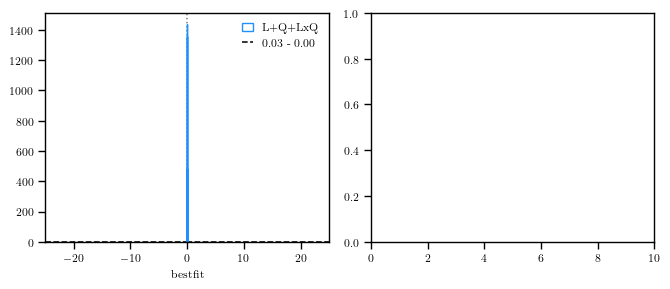

In [ ]:
tracers_to_plot = ['LRGxLRG-LRGxQSO-QSOxQSO']
kmin = '4e-03-4e-03-2e-03'
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, region, kmin, extra_fn, 50, xlim_fnl=25, xlim_fnlerr=10)

## I NEED TO UPDATE THIS WITH NEW PROGILES STRUCUEES --> 2/3 -> 1/2 !!


## 

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_55401/2207368690.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(fnl_vals, bins=20, density=True, color=f'C{i}', alpha=0.2, label=label + f'\n($\mu={mu:.1f}, \sigma={std:.1f}$)')
/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_55401/2207368690.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.his

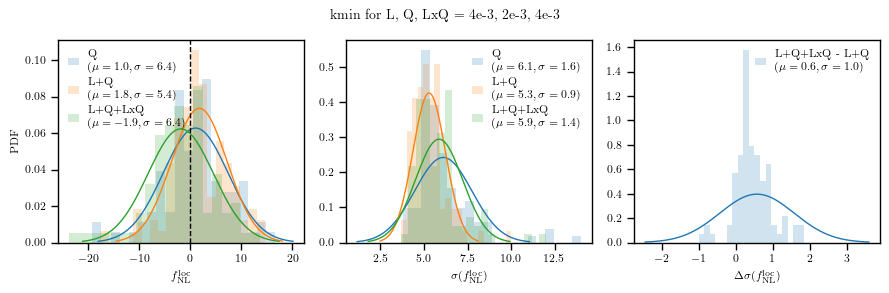

In [44]:
def get_index(profiles, params):
    """Get the row index of a named parameter in a bestfit/profile array (list of [name, value, ...])."""
    return np.where([profiles[i][0] == params for i in range(len(profiles))])[0][0]


plt.figure(figsize=(9, 3))

nmocks = 100

for i, (tt, kmin, label) in enumerate(zip(['QSOxQSO', 'LRGxLRG-QSOxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO'], 
                                          ['2e-03', '4e-03-2e-03', '4e-03-4e-03-2e-03'], 
                                          ['Q', 'L+Q', 'L+Q+LxQ'])):
    
    idx = get_index(profiles[tt]['GCcomb']['mock_cov'][kmin]['_RIC+AMR'][0], 'fnl_loc')
    fnl_vals = np.array([profiles[tt]['GCcomb']['mock_cov'][kmin]['_RIC+AMR'][i][idx][1] for i in range(nmocks)], dtype='float')
    fnl_errs = np.array([profiles[tt]['GCcomb']['mock_cov'][kmin]['_RIC+AMR'][i][idx][2] for i in range(nmocks)], dtype='float')

    plt.subplot(131)
    mu, std = np.mean(fnl_vals), np.std(fnl_vals)
    plt.hist(fnl_vals, bins=20, density=True, color=f'C{i}', alpha=0.2, label=label + f'\n($\mu={mu:.1f}, \sigma={std:.1f}$)')
    x = np.linspace(mu - 3 * std, mu + 3 * std, 500)
    pdf = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    plt.plot(x, pdf, color=f'C{i}', ls='-', lw=1)

    plt.subplot(132)
    mu, std = np.mean(fnl_errs), np.std(fnl_errs)
    plt.hist(fnl_errs, bins=20, density=True, color=f'C{i}', alpha=0.2, label=label + f'\n($\mu={mu:.1f}, \sigma={std:.1f}$)')
    x = np.linspace(mu - 3 * std, mu + 3 * std, 500)
    pdf = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    plt.plot(x, pdf, color=f'C{i}', ls='-', lw=1)

plt.subplot(131)
plt.axvline(0, ls='--', c='k', lw=1)
plt.xlabel(r'$f_{\rm NL}^{\rm loc}$')
plt.ylabel('PDF') 
plt.legend()

plt.subplot(132)
plt.xlabel(r'$\sigma(f_{\rm NL}^{\rm loc})$')
plt.legend()

plt.subplot(133)
idx = get_index(profiles['LRGxLRG-QSOxQSO']['GCcomb']['mock_cov']['4e-03-2e-03']['_RIC+AMR'][0], 'fnl_loc')
fnl_vals = np.array([profiles['LRGxLRG-QSOxQSO']['GCcomb']['mock_cov']['4e-03-2e-03']['_RIC+AMR'][i][idx][1] for i in range(nmocks)], dtype='float')
fnl_errs = np.array([profiles['LRGxLRG-QSOxQSO']['GCcomb']['mock_cov']['4e-03-2e-03']['_RIC+AMR'][i][idx][2] for i in range(nmocks)], dtype='float')

idx = get_index(profiles['LRGxLRG-LRGxQSO-QSOxQSO']['GCcomb']['mock_cov']['4e-03-4e-03-2e-03']['_RIC+AMR'][0], 'fnl_loc')
fnl_vals2 = np.array([profiles['LRGxLRG-LRGxQSO-QSOxQSO']['GCcomb']['mock_cov']['4e-03-4e-03-2e-03']['_RIC+AMR'][i][idx][1] for i in range(nmocks)], dtype='float')
fnl_errs2 = np.array([profiles['LRGxLRG-LRGxQSO-QSOxQSO']['GCcomb']['mock_cov']['4e-03-4e-03-2e-03']['_RIC+AMR'][i][idx][2] for i in range(nmocks)], dtype='float')

diff_val = fnl_vals2 - fnl_vals
diff_err = fnl_errs2 - fnl_errs

mu, std = np.mean(diff_err), np.std(diff_err)
plt.hist(diff_err, range=(-1, 2), bins=20, density=True, color=f'C0', alpha=0.2, label=f'L+Q+LxQ - L+Q\n($\mu={mu:.1f}, \sigma={std:.1f}$)')
x = np.linspace(mu - 3 * std, mu + 3 * std, 500)
pdf = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))
plt.plot(x, pdf, color=f'C0', ls='-', lw=1)

plt.xlabel(r'$\Delta \sigma(f_{\rm NL}^{\rm loc})$')
plt.legend()
plt.suptitle('kmin for L, Q, LxQ = 4e-3, 2e-3, 4e-3', fontsize=10, y=0.96)
plt.tight_layout()
plt.savefig('fig/Q-L+Q-L+Q+LxQ_fnl_distribution.png', dpi=400)
plt.show()

ATTENTION POUR LE BLINDING P=1 pour QSO donc le blinding est peute tere plus fort!? 


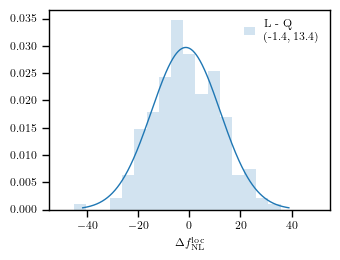

In [49]:
def get_index(profiles, params):
    """Get the row index of a named parameter in a bestfit/profile array (list of [name, value, ...])."""
    return np.where([profiles[i][0] == params for i in range(len(profiles))])[0][0]

print("ATTENTION POUR LE BLINDING P=1 pour QSO donc le blinding est peute tere plus fort!? ")

plt.figure(figsize=(3.5, 2.7))

nmocks = 200

idx = get_index(profiles['LRGxLRG']['GCcomb']['mock_cov']['4e-03']['_RIC+AMR'][0], 'fnl_loc')
fnl_vals = np.array([profiles['LRGxLRG']['GCcomb']['mock_cov']['4e-03']['_RIC+AMR'][i][idx][1] for i in range(nmocks)], dtype='float')
fnl_errs = np.array([profiles['LRGxLRG']['GCcomb']['mock_cov']['4e-03']['_RIC+AMR'][i][idx][2] for i in range(nmocks)], dtype='float')

idx = get_index(profiles['QSOxQSO']['GCcomb']['mock_cov']['2e-03']['_RIC+AMR'][0], 'fnl_loc')
fnl_vals2 = np.array([profiles['QSOxQSO']['GCcomb']['mock_cov']['2e-03']['_RIC+AMR'][i][idx][1] for i in range(nmocks)], dtype='float')
fnl_errs2 = np.array([profiles['QSOxQSO']['GCcomb']['mock_cov']['2e-03']['_RIC+AMR'][i][idx][2] for i in range(nmocks)], dtype='float')

diff_val = fnl_vals2 - fnl_vals
diff_err = fnl_errs2 - fnl_errs

mu, std = np.mean(diff_val), np.std(diff_val)
plt.hist(diff_val, range=(-50, 50), bins=21, density=True, color=f'C0', alpha=0.2, label=f'L - Q\n({mu:.1f}, {std:.1f})')
x = np.linspace(mu - 3 * std, mu + 3 * std, 500)
pdf = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))
plt.plot(x, pdf, color=f'C0', ls='-', lw=1)

plt.xlabel(r'$\Delta f_{\rm NL}^{\rm loc}$')
plt.legend()
#plt.grid(alpha=0.2, linestyle=(0, (1, 5)), zorder=0)
plt.tight_layout()
plt.savefig('fig/Q-L_fnl_distribution.png', dpi=400)
plt.show()